<a href="https://colab.research.google.com/github/B3nj4120/B3nj4120/blob/main/Evakuacion2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

tf.random.set_seed(42)
np.random.seed(42)

In [ ]:
df = pd.read_csv('/content/IMDB Dataset.csv (1).zip')

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
le = LabelEncoder()

df['sentiment'] = le.fit_transform(df['sentiment'])

X = df['review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train).toarray()
X_test_vec = vectorizer.transform(X_test).toarray()

print(X_train_vec.shape)
print(X_test_vec.shape)

(40000, 5000)
(10000, 5000)


In [ ]:
def evaluar_modelo(modelo, X_test, y_test):

    y_prob = modelo.predict(X_test, verbose=0)

    y_pred = (y_prob > 0.5).astype(int)

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    }

In [ ]:
def crear_baseline():

    modelo = Sequential([
        Dense(128, activation='relu', input_shape=(5000,)),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    modelo.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return modelo

In [ ]:
baseline = crear_baseline()

history_baseline = baseline.fit(
    X_train_vec,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

baseline_metrics = evaluar_modelo(
    baseline,
    X_test_vec,
    y_test
)

print(baseline_metrics)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.8682 - loss: 0.3124 - val_accuracy: 0.8746 - val_loss: 0.2905
Epoch 2/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9119 - loss: 0.2191 - val_accuracy: 0.8739 - val_loss: 0.3059
Epoch 3/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9471 - loss: 0.1475 - val_accuracy: 0.8677 - val_loss: 0.3649
Epoch 4/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9778 - loss: 0.0707 - val_accuracy: 0.8661 - val_loss: 0.4795
Epoch 5/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9835 - loss: 0.0448 - val_accuracy: 0.8689 - val_loss: 0.6180
Epoch 6/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9886 - loss: 0.0328 - val_accuracy: 0.8714 - val_loss: 0.6763
Epoch 7/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9954 - loss: 0.0168 - val_accuracy: 0.8684 - val_loss: 0.7868
Epoch 8/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9972 -

In [ ]:
def crear_l2_001():

    modelo = Sequential([
        Dense(
            128,
            activation='relu',
            kernel_regularizer=l2(0.001),
            input_shape=(5000,)
        ),
        Dense(
            64,
            activation='relu',
            kernel_regularizer=l2(0.001)
        ),
        Dense(1, activation='sigmoid')
    ])

    modelo.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return modelo

In [ ]:
modelo_l2_001 = crear_l2_001()

history_l2_001 = modelo_l2_001.fit(
    X_train_vec,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

l2_001_metrics = evaluar_modelo(
    modelo_l2_001,
    X_test_vec,
    y_test
)

print(l2_001_metrics)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.8597 - loss: 0.4612 - val_accuracy: 0.8500 - val_loss: 0.4529
Epoch 2/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.8766 - loss: 0.4035 - val_accuracy: 0.8537 - val_loss: 0.4325
Epoch 3/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.8800 - loss: 0.3797 - val_accuracy: 0.8597 - val_loss: 0.4079
Epoch 4/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.8866 - loss: 0.3527 - val_accuracy: 0.8666 - val_loss: 0.3826
Epoch 5/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.8932 - loss: 0.3314 - val_accuracy: 0.8705 - val_loss: 0.3688
Epoch 6/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.8977 - loss: 0.3165 - val_accuracy: 0.8726 - val_loss: 0.3596
Epoch 7/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9018 - loss: 0.3027 - val_accuracy: 0.8749 - val_loss: 0.3524
Epoch 8/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.9065 -

In [ ]:
def crear_l2_01():

    modelo = Sequential([
        Dense(
            128,
            activation='relu',
            kernel_regularizer=l2(0.01),
            input_shape=(5000,)
        ),
        Dense(
            64,
            activation='relu',
            kernel_regularizer=l2(0.01)
        ),
        Dense(1, activation='sigmoid')
    ])

    modelo.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return modelo

In [ ]:
modelo_l2_01 = crear_l2_01()

history_l2_01 = modelo_l2_01.fit(
    X_train_vec,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

l2_01_metrics = evaluar_modelo(
    modelo_l2_01,
    X_test_vec,
    y_test
)

print(l2_01_metrics)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.8177 - loss: 0.6988 - val_accuracy: 0.8261 - val_loss: 0.5929
Epoch 2/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.8584 - loss: 0.5395 - val_accuracy: 0.8351 - val_loss: 0.5419
Epoch 3/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.8690 - loss: 0.4935 - val_accuracy: 0.8475 - val_loss: 0.5031
Epoch 4/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.8742 - loss: 0.4640 - val_accuracy: 0.8569 - val_loss: 0.4772
Epoch 5/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.8783 - loss: 0.4421 - val_accuracy: 0.8608 - val_loss: 0.4585
Epoch 6/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.8816 - loss: 0.4253 - val_accuracy: 0.8625 - val_loss: 0.4442
Epoch 7/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.8842 - loss: 0.4115 - val_accuracy: 0.8636 - val_loss: 0.4329
Epoch 8/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.8863 -

In [ ]:
def crear_dropout_02():

    modelo = Sequential([
        Dense(128, activation='relu', input_shape=(5000,)),
        Dropout(0.2),

        Dense(64, activation='relu'),
        Dropout(0.2),

        Dense(1, activation='sigmoid')
    ])

    modelo.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return modelo

In [ ]:
modelo_dropout02 = crear_dropout_02()

history_dropout02 = modelo_dropout02.fit(
    X_train_vec,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

dropout02_metrics = evaluar_modelo(
    modelo_dropout02,
    X_test_vec,
    y_test
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.8638 - loss: 0.3198 - val_accuracy: 0.8809 - val_loss: 0.2814
Epoch 2/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9185 - loss: 0.2108 - val_accuracy: 0.8799 - val_loss: 0.2987
Epoch 3/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9520 - loss: 0.1406 - val_accuracy: 0.8740 - val_loss: 0.3557
Epoch 4/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9786 - loss: 0.0702 - val_accuracy: 0.8731 - val_loss: 0.4323
Epoch 5/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9873 - loss: 0.0389 - val_accuracy: 0.8701 - val_loss: 0.5950
Epoch 6/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9896 - loss: 0.0289 - val_accuracy: 0.8691 - val_loss: 0.7028
Epoch 7/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9927 - loss: 0.0214 - val_accuracy: 0.8685 - val_loss: 0.7752
Epoch 8/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9955 -

In [ ]:
def crear_dropout_05():

    modelo = Sequential([
        Dense(128, activation='relu', input_shape=(5000,)),
        Dropout(0.5),

        Dense(64, activation='relu'),
        Dropout(0.5),

        Dense(1, activation='sigmoid')
    ])

    modelo.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return modelo

In [ ]:
modelo_dropout05 = crear_dropout_05()

history_dropout05 = modelo_dropout05.fit(
    X_train_vec,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

dropout05_metrics = evaluar_modelo(
    modelo_dropout05,
    X_test_vec,
    y_test
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.8517 - loss: 0.3421 - val_accuracy: 0.8827 - val_loss: 0.2756
Epoch 2/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9138 - loss: 0.2230 - val_accuracy: 0.8841 - val_loss: 0.2864
Epoch 3/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.9356 - loss: 0.1787 - val_accuracy: 0.8792 - val_loss: 0.3195
Epoch 4/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.9551 - loss: 0.1304 - val_accuracy: 0.8759 - val_loss: 0.3722
Epoch 5/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9680 - loss: 0.0989 - val_accuracy: 0.8759 - val_loss: 0.4116
Epoch 6/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9784 - loss: 0.0689 - val_accuracy: 0.8704 - val_loss: 0.4661
Epoch 7/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9831 - loss: 0.0517 - val_accuracy: 0.8720 - val_loss: 0.5368
Epoch 8/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9853 -

In [ ]:
def crear_batchnorm():

    modelo = Sequential([

        Dense(128, input_shape=(5000,)),
        BatchNormalization(),
        tf.keras.layers.Activation('relu'),

        Dense(64),
        BatchNormalization(),
        tf.keras.layers.Activation('relu'),

        Dense(1, activation='sigmoid')
    ])

    modelo.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return modelo

In [ ]:
modelo_batchnorm = crear_batchnorm()

history_batchnorm = modelo_batchnorm.fit(
    X_train_vec,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

batchnorm_metrics = evaluar_modelo(
    modelo_batchnorm,
    X_test_vec,
    y_test
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.8550 - loss: 0.3344 - val_accuracy: 0.8826 - val_loss: 0.2790
Epoch 2/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9586 - loss: 0.1218 - val_accuracy: 0.8615 - val_loss: 0.3953
Epoch 3/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9905 - loss: 0.0352 - val_accuracy: 0.8626 - val_loss: 0.5324
Epoch 4/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9907 - loss: 0.0303 - val_accuracy: 0.8561 - val_loss: 0.5931
Epoch 5/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9910 - loss: 0.0266 - val_accuracy: 0.8589 - val_loss: 0.6496
Epoch 6/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9949 - loss: 0.0167 - val_accuracy: 0.8606 - val_loss: 0.6736
Epoch 7/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9966 - loss: 0.0116 - val_accuracy: 0.8633 - val_loss: 0.7252
Epoch 8/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9975 -

In [ ]:
early_stop_5 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
modelo_es5 = crear_baseline()

history_es5 = modelo_es5.fit(
    X_train_vec,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop_5]
)

earlystop5_metrics = evaluar_modelo(
    modelo_es5,
    X_test_vec,
    y_test
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.8708 - loss: 0.3125 - val_accuracy: 0.8734 - val_loss: 0.2899
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9122 - loss: 0.2190 - val_accuracy: 0.8740 - val_loss: 0.3060
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9463 - loss: 0.1498 - val_accuracy: 0.8679 - val_loss: 0.3739
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9789 - loss: 0.0672 - val_accuracy: 0.8664 - val_loss: 0.4867
Epoch 5/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9863 - loss: 0.0379 - val_accuracy: 0.8704 - val_loss: 0.6147
Epoch 6/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9896 - loss: 0.0294 - val_accuracy: 0.8689 - val_loss: 0.7137


In [ ]:
early_stop_20 = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

In [ ]:
modelo_es20 = crear_baseline()

history_es20 = modelo_es20.fit(
    X_train_vec,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop_20]
)

earlystop20_metrics = evaluar_modelo(
    modelo_es20,
    X_test_vec,
    y_test
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.8682 - loss: 0.3122 - val_accuracy: 0.8737 - val_loss: 0.2895
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9126 - loss: 0.2177 - val_accuracy: 0.8723 - val_loss: 0.3065
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9465 - loss: 0.1487 - val_accuracy: 0.8692 - val_loss: 0.3678
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9790 - loss: 0.0689 - val_accuracy: 0.8669 - val_loss: 0.4822
Epoch 5/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9865 - loss: 0.0399 - val_accuracy: 0.8695 - val_loss: 0.6048
Epoch 6/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9896 - loss: 0.0315 - val_accuracy: 0.8673 - val_loss: 0.7092
Epoch 7/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9942 - loss: 0.0185 - val_accuracy: 0.8698 - val_loss: 0.7489
Epoch 8/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9962 -

In [ ]:
def crear_modelo_final():

    modelo = Sequential([

        Dense(
            128,
            activation='relu',
            kernel_regularizer=l2(0.001),
            input_shape=(5000,)
        ),

        BatchNormalization(),

        Dropout(0.3),

        Dense(
            64,
            activation='relu',
            kernel_regularizer=l2(0.001)
        ),

        BatchNormalization(),

        Dropout(0.3),

        Dense(1, activation='sigmoid')
    ])

    modelo.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return modelo

In [ ]:
modelo_final = crear_modelo_final()

history_final = modelo_final.fit(
    X_train_vec,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop_5]
)

final_metrics = evaluar_modelo(
    modelo_final,
    X_test_vec,
    y_test
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.8374 - loss: 0.6169 - val_accuracy: 0.8769 - val_loss: 0.5062
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.8869 - loss: 0.4787 - val_accuracy: 0.8695 - val_loss: 0.5184
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.8977 - loss: 0.4733 - val_accuracy: 0.8701 - val_loss: 0.5574
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.9079 - loss: 0.4733 - val_accuracy: 0.8631 - val_loss: 0.6174
Epoch 5/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.9192 - loss: 0.4627 - val_accuracy: 0.8679 - val_loss: 0.6156


In [ ]:
resultados = pd.DataFrame([
    baseline_metrics,
    l2_001_metrics,
    l2_01_metrics,
    dropout02_metrics,
    dropout05_metrics,
    batchnorm_metrics,
    earlystop5_metrics,
    earlystop20_metrics,
    final_metrics
])

resultados.index = [
    "Baseline",
    "L2_0.001",
    "L2_0.01",
    "Dropout_0.2",
    "Dropout_0.5",
    "BatchNorm",
    "EarlyStop_5",
    "EarlyStop_20",
    "Modelo_Final"
]

resultados

,Accuracy,Precision,Recall,F1
Baseline,0.8774,0.866846,0.894027,0.880227
L2_0.001,0.8747,0.884287,0.864457,0.874260
L2_0.01,0.8747,0.922545,0.820202,0.868369
Dropout_0.2,0.8751,0.870262,0.883906,0.877031
Dropout_0.5,0.8766,0.860937,0.900576,0.880310
BatchNorm,0.8591,0.837486,0.893828,0.864740
EarlyStop_5,0.8822,0.909960,0.850367,0.879155
EarlyStop_20,0.8829,0.909572,0.852352,0.880033
Modelo_Final,0.8877,0.893805,0.881921,0.887823


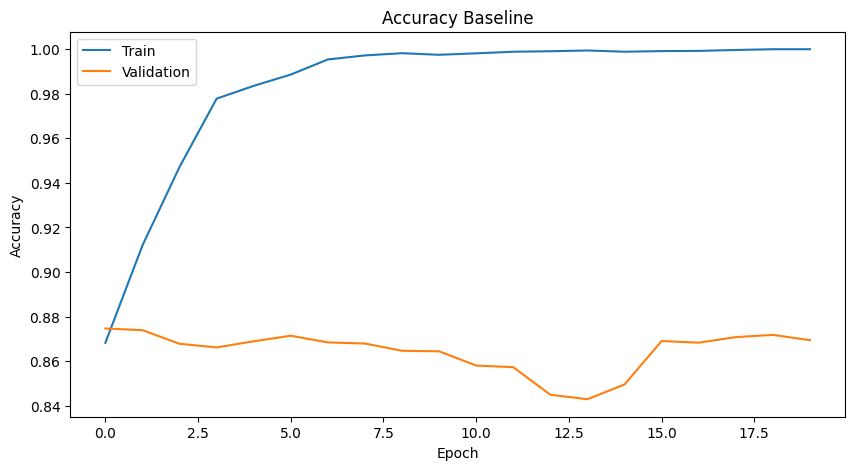

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history_baseline.history['accuracy'])
plt.plot(history_baseline.history['val_accuracy'])

plt.title('Accuracy Baseline')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

plt.show()

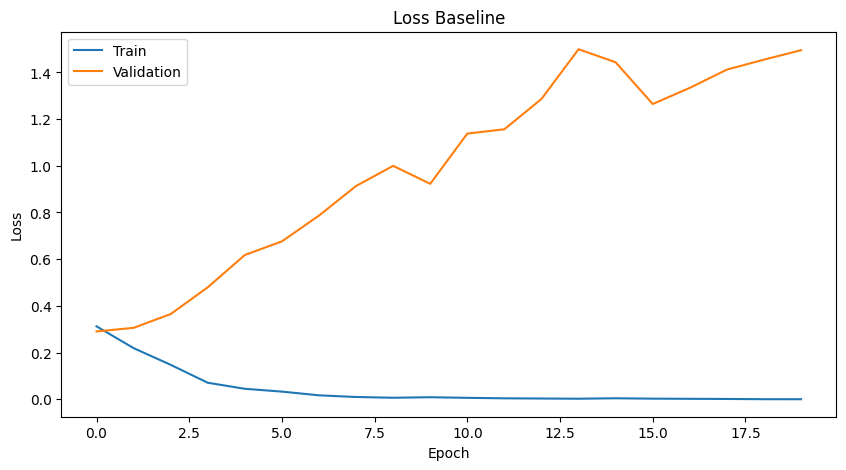

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history_baseline.history['loss'])
plt.plot(history_baseline.history['val_loss'])

plt.title('Loss Baseline')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])

plt.show()